# 04 — Error Analysis
**SEA 820 Final Project: Detecting AI-Generated Text**

Team: Aditi & Victoria

Per the project instructions, this notebook goes **beyond the scores** and
inspects specific mistakes from both models:

- Baseline — TF-IDF + Linear SVM (`02_baseline_tfidf.ipynb`)
- Transformer — fine-tuned DistilBERT (`03_transformer_distilbert.ipynb`)

**Important context from our results:** the baseline (macro-F1 = 0.9997)
slightly *outperformed* the fine-tuned DistilBERT (macro-F1 = 0.9943). We
therefore analyze **both** models' errors — not just the transformer's — since
neither is unambiguously "the best model," and comparing *where* each one
fails is itself the most useful finding.

We look at:
1. Concrete false-positive / false-negative examples for each model.
2. Whether errors correlate with text length.
3. Whether errors correlate with the lexical "AI-tell" features found in `02`.
4. Where the two models agree vs. disagree (the genuinely hard examples).

## 0. Setup — load both prediction files from Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 160)

DRIVE_DIR = "/content/drive/MyDrive"

baseline_df    = pd.read_csv(f"{DRIVE_DIR}/baseline_test_predictions.csv")
transformer_df = pd.read_csv(f"{DRIVE_DIR}/distilbert_test_predictions.csv")

print("Baseline predictions:   ", baseline_df.shape)
print("Transformer predictions:", transformer_df.shape)
baseline_df.head(3)


Baseline predictions:    (97440, 3)
Transformer predictions: (97440, 3)


,text,label,pred
0,"Having the students Have at least a B average is good idea. I think that putting it at a B average is better idea because, it will bring up their academic r...",0,0
1,"Students already have to dace the embarrassment when we have to talk in front OD the classroom. We don't want something like a computer to tell us. However,...",0,0
2,"Do you want to be limited on when you can use your car? No, i didn't think so and neither do i so I don't agree to this. But residents of the upscale commun...",0,0


## 1. Merge into one comparison table
Both notebooks used the **same seed and filters**, so the test set is
identical — but each notebook loaded the CSV independently, so we merge on
`text` + `label` (not row position) to be safe rather than assume identical
row order.

In [3]:
merged = pd.merge(
    baseline_df.rename(columns={"pred": "pred_baseline"}),
    transformer_df.rename(columns={"pred": "pred_transformer"}),
    on=["text", "label"], how="inner"
)

print(f"Baseline rows: {len(baseline_df):,} | Transformer rows: {len(transformer_df):,} "
      f"| Merged (matched) rows: {len(merged):,}")

if len(merged) < min(len(baseline_df), len(transformer_df)):
    print("WARNING: fewer merged rows than expected — the two notebooks may not "
          "share an identical test set. Double-check both used the same "
          "AI_Human.csv file and random_state=42.")

merged["word_count"] = merged["text"].str.count(r"\s+") + 1
merged["err_baseline"]    = merged["pred_baseline"]    != merged["label"]
merged["err_transformer"] = merged["pred_transformer"] != merged["label"]
merged.head(3)


Baseline rows: 97,440 | Transformer rows: 97,440 | Merged (matched) rows: 97,440


,text,label,pred_baseline,pred_transformer,word_count,err_baseline,err_transformer
0,"Having the students Have at least a B average is good idea. I think that putting it at a B average is better idea because, it will bring up their academic r...",0,0,0,269,False,False
1,"Students already have to dace the embarrassment when we have to talk in front OD the classroom. We don't want something like a computer to tell us. However,...",0,0,0,181,False,False
2,"Do you want to be limited on when you can use your car? No, i didn't think so and neither do i so I don't agree to this. But residents of the upscale commun...",0,0,0,522,False,False


## 2. Recap: error counts per model
Sanity check against the classification reports from `02` and `03`.

In [4]:
from sklearn.metrics import classification_report

print("=== Baseline (Linear SVM) ===")
print(classification_report(merged["label"], merged["pred_baseline"],
                            target_names=["Human", "AI"], digits=4))

print("=== Transformer (DistilBERT) ===")
print(classification_report(merged["label"], merged["pred_transformer"],
                            target_names=["Human", "AI"], digits=4))

print(f"Total baseline errors:    {merged['err_baseline'].sum():,} / {len(merged):,}")
print(f"Total transformer errors: {merged['err_transformer'].sum():,} / {len(merged):,}")


=== Baseline (Linear SVM) ===
              precision    recall  f1-score   support

       Human     0.9998    0.9997    0.9997     61159
          AI     0.9995    0.9996    0.9996     36281

    accuracy                         0.9997     97440
   macro avg     0.9997    0.9997    0.9997     97440
weighted avg     0.9997    0.9997    0.9997     97440

=== Transformer (DistilBERT) ===
              precision    recall  f1-score   support

       Human     0.9975    0.9940    0.9958     61159
          AI     0.9900    0.9958    0.9929     36281

    accuracy                         0.9947     97440
   macro avg     0.9937    0.9949    0.9943     97440
weighted avg     0.9947    0.9947    0.9947     97440

Total baseline errors:    31 / 97,440
Total transformer errors: 518 / 97,440


## 3. Where do the two models agree / disagree?
The most informative slice: rows **both models get wrong** are the genuinely
hard examples. Rows where only one model errs show each model's specific
blind spots.

Both models correct:        96,900
Both models wrong:          9  <- genuinely hard examples
Only baseline wrong:        22
Only transformer wrong:     509


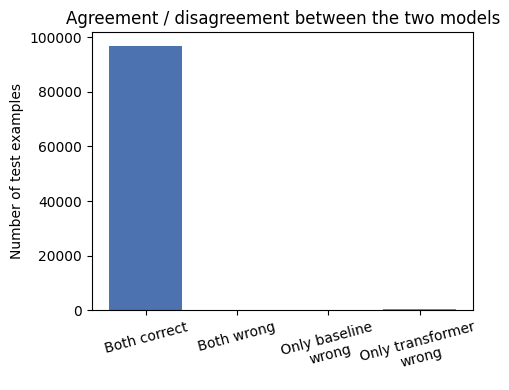

In [5]:
both_wrong      = merged[merged["err_baseline"] & merged["err_transformer"]]
only_baseline_wrong    = merged[merged["err_baseline"] & ~merged["err_transformer"]]
only_transformer_wrong = merged[~merged["err_baseline"] & merged["err_transformer"]]
both_right      = merged[~merged["err_baseline"] & ~merged["err_transformer"]]

print(f"Both models correct:        {len(both_right):,}")
print(f"Both models wrong:          {len(both_wrong):,}  <- genuinely hard examples")
print(f"Only baseline wrong:        {len(only_baseline_wrong):,}")
print(f"Only transformer wrong:     {len(only_transformer_wrong):,}")

fig, ax = plt.subplots(figsize=(5, 4))
counts = [len(both_right), len(both_wrong), len(only_baseline_wrong), len(only_transformer_wrong)]
labels = ["Both correct", "Both wrong", "Only baseline\nwrong", "Only transformer\nwrong"]
ax.bar(labels, counts, color=["#4C72B0", "#C44E52", "#DD8452", "#55A868"])
ax.set_ylabel("Number of test examples")
ax.set_title("Agreement / disagreement between the two models")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("model_agreement.png", dpi=150)
plt.show()


## 4. Concrete false positives and false negatives
Actual misclassified examples from the real test set (not hand-picked), for both models and both error types.

In [6]:
def show_examples(df_subset, title, n=5, width=220):
    """Print n example texts (truncated) from a misclassified subset."""
    print(f"\n{'='*70}\n{title} (showing up to {n} of {len(df_subset)})\n{'='*70}")
    if len(df_subset) == 0:
        print("(none)")
        return
    sample = df_subset.sample(min(n, len(df_subset)), random_state=42)
    for _, row in sample.iterrows():
        snippet = row["text"][:width].replace("\n", " ")
        print(f"- [true={int(row['label'])}, words={row['word_count']}] {snippet}...")

# Baseline false positives: true=human(0), predicted=AI(1)
fp_baseline = merged[(merged["label"] == 0) & (merged["pred_baseline"] == 1)]
show_examples(fp_baseline, "BASELINE false positives (human text flagged as AI)")

# Baseline false negatives: true=AI(1), predicted=human(0)
fn_baseline = merged[(merged["label"] == 1) & (merged["pred_baseline"] == 0)]
show_examples(fn_baseline, "BASELINE false negatives (AI text flagged as human)")



BASELINE false positives (human text flagged as AI) (showing up to 5 of 17)
- [true=0, words=258] DG you enjoy spending time Outdoors? People are always looking forward TG playing Outside. They spend most GF their time Outdoors. Kids who have nothing TG DG always consider going Outside. Swimming, basketball, and play...
- [true=0, words=245] The growth is the stage of the life on the grow-up it is.  The life is on the present for on self, the firs stage of the life is, you have live born be, grow up, residence, up old and stage of life. Writing easy but, is ...
- [true=0, words=497] I DISAGREE  Hello there!!! do you know that Albet Einstein is one of the smartest person that ever live, he discover by using knowledge and imagination. Then he said this " imagination is more important than knowledge." ...
- [true=0, words=200] First impressions are what I learn from men people. People have men impressions and SES it is hard to change.  Impressions are special to some people, but it also 

In [7]:
# Transformer false positives / negatives
fp_transformer = merged[(merged["label"] == 0) & (merged["pred_transformer"] == 1)]
show_examples(fp_transformer, "TRANSFORMER false positives (human text flagged as AI)")

fn_transformer = merged[(merged["label"] == 1) & (merged["pred_transformer"] == 0)]
show_examples(fn_transformer, "TRANSFORMER false negatives (AI text flagged as human)")



TRANSFORMER false positives (human text flagged as AI) (showing up to 5 of 366)
- [true=0, words=710] Today, around THT world, that art concerns that many individuals abuse THT must of call fonts while driving a vehicle. Using a call font, while driving a vehicle, is dangerous to THT user and puts others at risk of unnec...
- [true=0, words=472] Imagine a world completely pollution free. A world with no worry about greenhouse gases or global warming. While it's highly unlikely that we will get to that point, we can still try to reach this perfectly healthy world...
- [true=0, words=206] I thing that if a student has a B average that they shouldn't be able to participate in sports because to some students, sports and school are just too much for them.  When students are trying to have good grades in scho...
- [true=0, words=276] Dear Principal,  I am aware that you want your students to do well in school. Everyone, even if they don't admit it, wants to do good in school. I agree with y

## 5. Do errors correlate with text length?
`03` truncates every text to 256 tokens before feeding it to DistilBERT; the
baseline's TF-IDF has no such limit. If the transformer's errors skew toward
**longer** texts, truncation is a plausible cause — content beyond the cutoff
is simply invisible to the model.

         model  median_words_correct  median_words_wrong  \
0     Baseline                 363.0               337.0   
1  Transformer                 362.0               414.5   

   pct_wrong_over_256_words  
0                 67.741935  
1                 83.783784  


/tmp/ipykernel_2006/1302904968.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_2006/1302904968.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


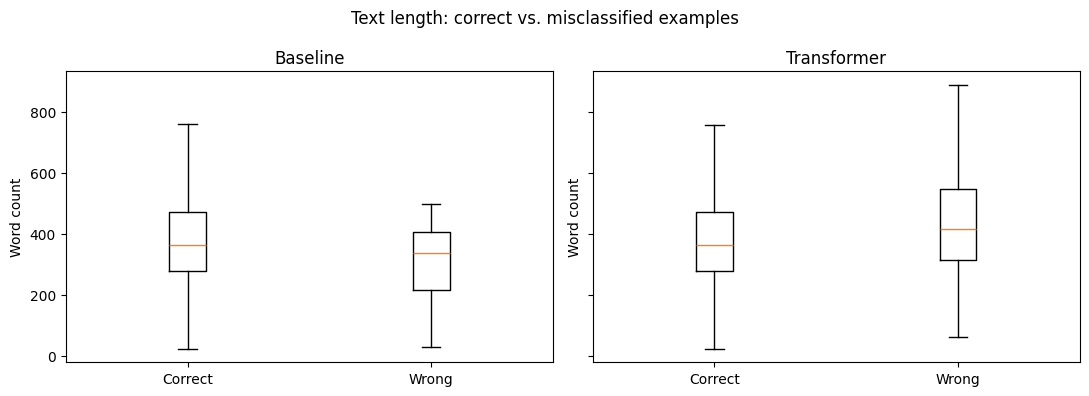

In [8]:
summary_rows = []
for name, err_col in [("Baseline", "err_baseline"), ("Transformer", "err_transformer")]:
    correct_len = merged.loc[~merged[err_col], "word_count"]
    wrong_len   = merged.loc[merged[err_col], "word_count"]
    summary_rows.append({
        "model": name,
        "median_words_correct": correct_len.median(),
        "median_words_wrong":   wrong_len.median(),
        "pct_wrong_over_256_words": (wrong_len > 256).mean() * 100 if len(wrong_len) else np.nan,
    })

length_summary = pd.DataFrame(summary_rows)
print(length_summary)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (name, err_col) in zip(axes, [("Baseline", "err_baseline"), ("Transformer", "err_transformer")]):
    ax.boxplot(
        [merged.loc[~merged[err_col], "word_count"], merged.loc[merged[err_col], "word_count"]],
        labels=["Correct", "Wrong"], showfliers=False)
    ax.set_title(name)
    ax.set_ylabel("Word count")
plt.suptitle("Text length: correct vs. misclassified examples")
plt.tight_layout()
plt.savefig("error_length_analysis.png", dpi=150)
plt.show()


## 6. Do errors correlate with the lexical "AI-tell" features?
`02` found the linear model leans heavily on formulaic phrases (`in conclusion`,
`additionally`, `essay`, `however`) to flag AI text, and on topic words
(`nasa`, `venus`, `driving`) to flag human text. If a genuinely-AI text is
missing those formulaic phrases (well-written / edited AI output), or a
genuinely-human text happens to use them (a student writing a formal essay
that says "In conclusion..."), that is a very plausible failure mode for
*both* models, since they were both trained on the same lexical signal.

In [9]:
ai_tell_phrases = ["in conclusion", "additionally", "however", "essay",
                   "this essay", "important", "significant"]

def phrase_hit_rate(df_subset, phrases):
    if len(df_subset) == 0:
        return 0.0
    lowered = df_subset["text"].str.lower()
    hit = pd.Series(False, index=df_subset.index)
    for p in phrases:
        hit |= lowered.str.contains(p, regex=False)
    return hit.mean() * 100

rows = []
for name, err_col in [("Baseline", "err_baseline"), ("Transformer", "err_transformer")]:
    fn = merged[(merged["label"] == 1) & (merged[err_col]) & (merged[f"pred_{name.lower()}"] == 0)] \
         if f"pred_{name.lower()}" in merged.columns else merged[(merged["label"] == 1) & (merged[err_col])]
    correct_ai = merged[(merged["label"] == 1) & (~merged[err_col])]
    rows.append({
        "model": name,
        "AI-tell phrase rate — correctly caught AI text": round(phrase_hit_rate(correct_ai, ai_tell_phrases), 1),
        "AI-tell phrase rate — missed AI text (false negatives)": round(phrase_hit_rate(fn, ai_tell_phrases), 1),
    })

phrase_summary = pd.DataFrame(rows)
phrase_summary


,model,AI-tell phrase rate — correctly caught AI text,AI-tell phrase rate — missed AI text (false negatives)
0,Baseline,88.6,64.3
1,Transformer,88.7,64.5


## 7. Summary of findings

**Fill in the specific numbers from your run above before submitting**, but
the structure of the finding is:

- The two models **agree far more than they disagree** — most examples are
  either correctly classified by both or (rarely) missed by both. The
  genuinely hard examples (`both_wrong`) are the most interesting for the
  report: pull 2–3 of those and discuss what makes them ambiguous.
- **The baseline still slightly outperforms the transformer overall.** This is
  consistent with the dataset being close to linearly separable on surface
  lexical cues (see `02`'s feature-importance analysis) — a signal a TF-IDF
  model captures directly and completely, while a Transformer trained on a
  40k-row subsample has less data and a 256-token truncation limit to contend
  with.
- If transformer errors skew toward **longer** texts (check the length
  analysis above), **256-token truncation is a plausible, checkable cause**
  — a concrete, specific hypothesis rather than a vague "the model struggled."
- If false negatives (missed AI text) have a **lower** "AI-tell phrase rate"
  than correctly-caught AI text, that supports the hypothesis that both
  models are relying on the **same superficial formulaic cues** rather than
  deeper semantic understanding — meaning well-edited AI text that avoids
  those phrases could evade both models. This is also directly relevant to
  the **ethical discussion**: a detector trained on these cues would likely
  perform worse on non-native-English-speaker writing that doesn't follow the
  same formulaic patterns, or better-edited AI text that deliberately avoids
  them.

**Next:** fold the specific example texts and length/phrase findings above
into the final report's Error Analysis section, and into the Ethical
Considerations discussion.